
# Task 4.1 Supervised Learning - Regression
Sneha Sivakaran

In [9]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [12]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/heartdata.csv',
index_col=0)
print(df.shape)
df.head()

(498, 3)


,biking,smoking,heartdisease
1,30.801246,10.896608,11.769423
2,65.129215,2.219563,2.854081
3,1.959665,17.588331,17.177803
4,44.800196,2.802559,6.816647
5,69.428454,15.974505,4.062224


# **3. Check Assumptions**

                biking   smoking  heartdisease
biking        1.000000  0.015136     -0.935455
smoking       0.015136  1.000000      0.309131
heartdisease -0.935455  0.309131      1.000000
Biking:  r=-0.935, p=0.0000
Smoking: r=0.309, p=0.0000


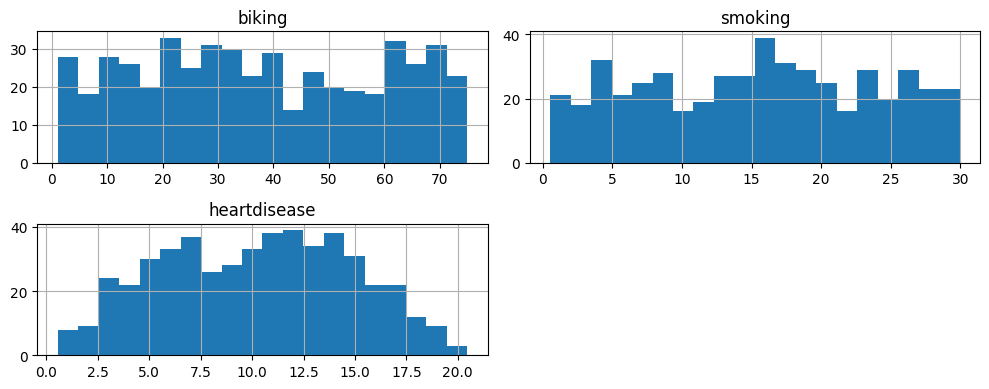

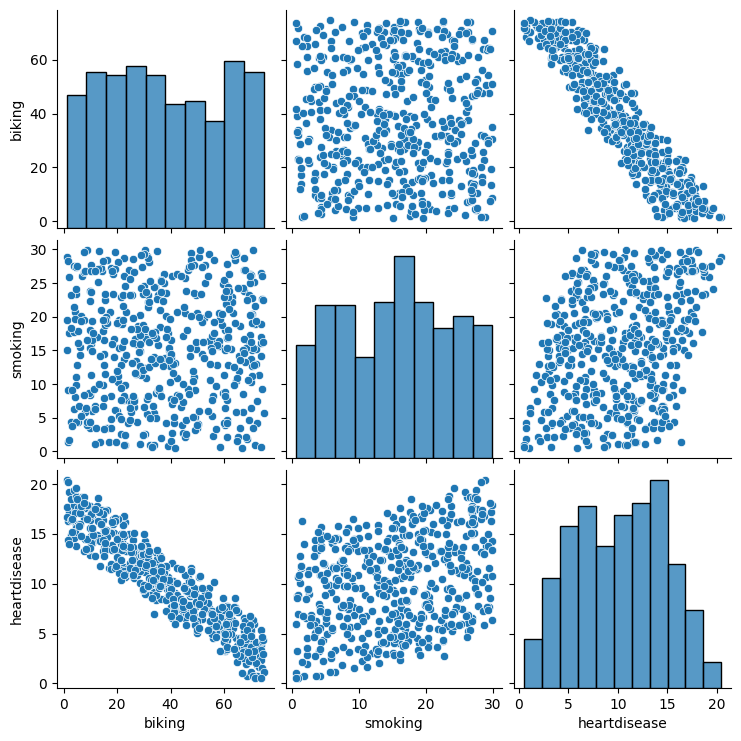

In [13]:
# Check how strongly each variable is correlated with the others
print(df.corr())

# Test the linear relationship between each predictor and the target variable
r_bike, p_bike = stats.pearsonr(df['biking'], df['heartdisease'])
r_smoke, p_smoke = stats.pearsonr(df['smoking'], df['heartdisease'])

print(f"Biking:  r={r_bike:.3f}, p={p_bike:.4f}")
print(f"Smoking: r={r_smoke:.3f}, p={p_smoke:.4f}")

# Check if the variables are roughly normally distributed
df[['biking', 'smoking', 'heartdisease']].hist(bins=20, figsize=(10, 4))
plt.tight_layout()
plt.show()

# Visualize the relationships between all variables to check for linearity
sns.pairplot(df[['biking', 'smoking', 'heartdisease']])
plt.show()


# **4. Fit a Linear Regression Model**

In [14]:
# Define features (X) and target variable (y)
X = df[['biking', 'smoking']]
y = df['heartdisease']

# Create and fit the linear regression model on the full dataset
model = LinearRegression()
model.fit(X, y)

# Print the intercept and coefficients to understand the model equation
print("Intercept:", model.intercept_)
print("Coefficients:", dict(zip(X.columns, model.coef_)))

# Evaluate the model performance using R² (1.0 = perfect fit)
print("R² (full data):", r2_score(y, model.predict(X)))

Intercept: 14.984657987225846
Coefficients: {'biking': np.float64(-0.20013305195862294), 'smoking': np.float64(0.17833391383818578)}
R² (full data): 0.9796174523377278


# **5. Train/Test Split & Evaluation**

In [15]:
# Split data into 80% training and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model only on the training data
model_cv = LinearRegression()
model_cv.fit(X_train, y_train)

# Predict on the test set and evaluate with R²
y_pred = model_cv.predict(X_test)
print("R² (test set):", r2_score(y_test, y_pred))

R² (test set): 0.9751106638392245


# **6. Visualize Predictions**

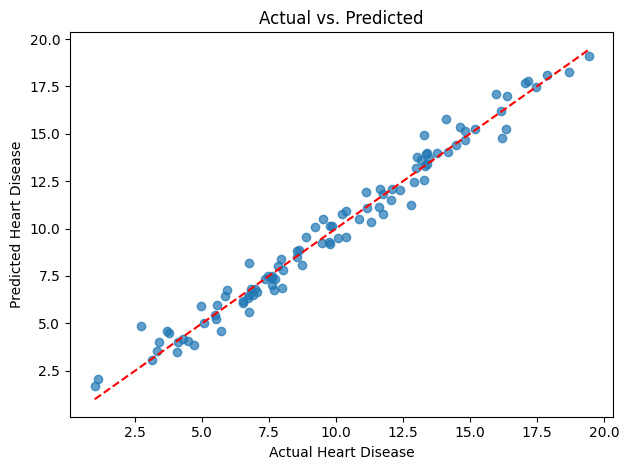

In [16]:
# Scatter plot of actual vs. predicted values
# Points close to the red line = good predictions
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Heart Disease")
plt.ylabel("Predicted Heart Disease")
plt.title("Actual vs. Predicted")
plt.tight_layout()
plt.show()

# **7. Interpretation**

Biking shows a strong negative correlation with heart disease,
while smoking shows a positive one. The model achieves a high R² (~0.98),
suggesting the two predictors explain most of the variance in heart disease rates.